[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/imbishal7/CSC-428/blob/main/notebooks/CSC428_project.ipynb)

# CSC428 Final Project — ML Side-Channel Attack on AES (ASCAD)

Suwan Aryal & Kapil Sharma. We train classifiers to recover the Hamming weight of an AES key byte from power-trace measurements collected on an ATMega8515 microcontroller.

**Pipeline:**

1. Data downloading and loading
2. Data cleaning
3. Train / validation / test split
4. Define, train, validate, and test three models — Logistic Regression, MLP, CNN
5. Compare results

## Section 0 — Colab setup
Mount Drive, clone the repo (first run only), install dependencies.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive
![ -d CSC-428 ] || git clone https://github.com/imbishal7/CSC-428.git
%cd CSC-428
!pip install -q -r requirements.txt
!nvidia-smi -L

Mounted at /content/drive
/content/drive/MyDrive
/content/drive/MyDrive/CSC-428
GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-6716ffa9-5994-aa00-cafd-5e4881051b88)


## 1. Data downloading and loading

ASCAD is published by ANSSI as a single ~4.2 GB zip. The download script grabs it and extracts `ASCAD.h5` into `data/`; it skips work that's already done.

The file holds 60,000 power traces (50,000 profiling + 10,000 attack), each 700 samples long. The implementation under attack is **boolean-masked AES**: the Sbox computation is randomized at runtime so what the trace directly leaks is `Sbox(p ^ k) ^ mask_out`, not `Sbox(p ^ k)` itself. We load the unmasked label *and* the per-trace masks; section 2 picks the right mask byte and combines them into the label the model can actually learn.


In [2]:
!python scripts/download_data.py

already present: data/ASCAD.h5 (0.05 GB)


In [3]:
import h5py
import numpy as np

HW_TABLE = np.array([bin(i).count('1') for i in range(256)], dtype=np.int64)

with h5py.File('data/ASCAD.h5', 'r') as f:
    X_train_full = np.array(f['Profiling_traces/traces'],            dtype=np.float32)
    sbox_train   = np.array(f['Profiling_traces/labels'],            dtype=np.int64)
    masks_train  = np.array(f['Profiling_traces/metadata']['masks'], dtype=np.int64)
    X_test       = np.array(f['Attack_traces/traces'],               dtype=np.float32)
    sbox_test    = np.array(f['Attack_traces/labels'],               dtype=np.int64)
    masks_test   = np.array(f['Attack_traces/metadata']['masks'],    dtype=np.int64)

print('profiling traces:', X_train_full.shape, '  unmasked-Sbox labels:', sbox_train.shape)
print('attack traces:   ', X_test.shape,       '  unmasked-Sbox labels:', sbox_test.shape)
print('mask bytes per trace:', masks_train.shape[1])


profiling traces: (50000, 700)   unmasked-Sbox labels: (50000,)
attack traces:    (10000, 700)   unmasked-Sbox labels: (10000,)
mask bytes per trace: 16


## 2. Data cleaning + label engineering

Two things happen here.

**(a) Sanity checks.** Verify there are no NaN / Inf values and look at the trace + class distributions.

**(b) Pick the right label.** This is the critical step. The naive label `HW(Sbox(p ^ k))` looks reasonable, but on masked AES it has near-zero correlation with any single trace point — the mask randomizes it out. We compute per-sample SNR for every candidate `HW(Sbox(p ^ k) ^ masks[:, m])` and pick the mask byte `m` whose label gives the highest peak SNR. That label is the one the trace actually leaks.

> **Caveat for the report.** Using the masks at training time is a profiling-attack assumption (the attacker has full control of a clone device and can read its masks). At attack time on an unknown target, you'd need higher-order analysis to combine multiple time points where the input mask, the masked Sbox, and the output mask each leak separately. We're showing what's learnable in principle; a real unknown-mask attack is the next problem.


no NaN / Inf
per-mask peak SNR: [2.3975, 0.0022, 0.0025, 0.0027, 0.0018, 0.002, 0.0027, 0.0018, 0.0023, 0.0029, 0.0019, 0.002, 0.0016, 0.0017, 0.0016, 0.7496]
best mask byte: index 0  (SNR 2.398  vs unmasked SNR 0.0016)
class distribution (masked-HW): [212, 1569, 5542, 10885, 13747, 10860, 5381, 1605, 199]  -- still binomial, peak at HW=4


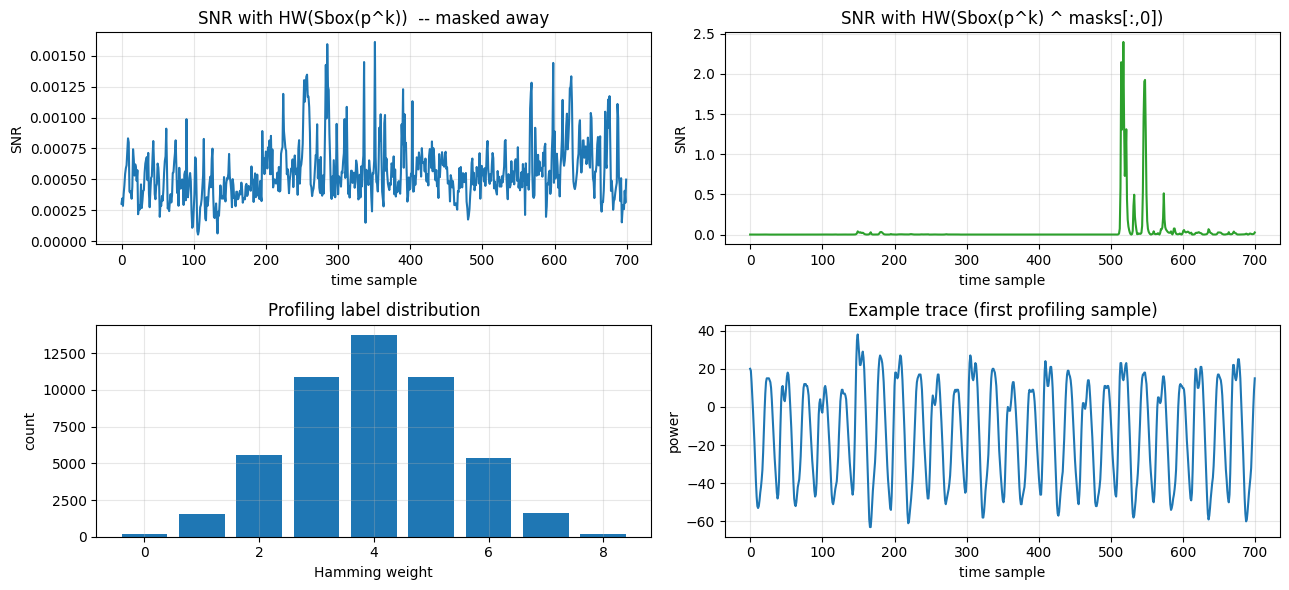

standardized: (50000, 700) (10000, 700)


In [4]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pathlib import Path

Path('results').mkdir(exist_ok=True)

assert not np.isnan(X_train_full).any() and not np.isinf(X_train_full).any(), 'NaN/Inf in profiling traces'
assert not np.isnan(X_test).any()       and not np.isinf(X_test).any(),       'NaN/Inf in attack traces'
print('no NaN / Inf')

def per_sample_snr(traces, labels, n_classes=9):
    """Between-class variance / within-class variance per time sample."""
    means = np.zeros((n_classes, traces.shape[1]), dtype=np.float64)
    var_w = np.zeros_like(means)
    counts = np.zeros(n_classes, dtype=np.int64)
    for c in range(n_classes):
        sl = labels == c
        n = int(sl.sum())
        counts[c] = n
        if n == 0:
            continue
        sub = traces[sl].astype(np.float64)
        means[c] = sub.mean(axis=0)
        var_w[c] = sub.var(axis=0)
    grand = (means * counts[:, None]).sum(0) / counts.sum()
    w = counts[:, None] / counts.sum()
    var_b = ((means - grand) ** 2 * w).sum(0)
    return var_b / np.maximum((var_w * w).sum(0), 1e-12)

# Auto-detect the right mask byte using a 10k-trace slice
N_DIAG = min(10000, X_train_full.shape[0])
snr_per_mask = []
for m_idx in range(masks_train.shape[1]):
    cand = HW_TABLE[(sbox_train[:N_DIAG] ^ masks_train[:N_DIAG, m_idx]) & 0xff]
    snr_per_mask.append(per_sample_snr(X_train_full[:N_DIAG], cand).max())
snr_per_mask = np.array(snr_per_mask)
best_mask = int(snr_per_mask.argmax())
snr_unmasked = per_sample_snr(X_train_full[:N_DIAG], HW_TABLE[sbox_train[:N_DIAG]])

print(f'per-mask peak SNR: {snr_per_mask.round(4).tolist()}')
print(f'best mask byte: index {best_mask}  (SNR {snr_per_mask[best_mask]:.3f}  vs unmasked SNR {snr_unmasked.max():.4f})')
assert snr_per_mask[best_mask] > 10 * snr_unmasked.max(), 'no mask byte clearly dominates -- dataset layout may differ'

# Build the labels we'll actually train on
y_train_full = HW_TABLE[(sbox_train ^ masks_train[:, best_mask]) & 0xff]
y_test       = HW_TABLE[(sbox_test  ^ masks_test [:, best_mask]) & 0xff]
counts = np.bincount(y_train_full, minlength=9)
print(f'class distribution (masked-HW): {counts.tolist()}  -- still binomial, peak at HW={counts.argmax()}')

snr_best = per_sample_snr(X_train_full[:N_DIAG], y_train_full[:N_DIAG])
fig, ax = plt.subplots(2, 2, figsize=(13, 6))
ax[0, 0].plot(snr_unmasked);                 ax[0, 0].set(title='SNR with HW(Sbox(p^k))  -- masked away',                  xlabel='time sample', ylabel='SNR')
ax[0, 1].plot(snr_best, color='tab:green');  ax[0, 1].set(title=f'SNR with HW(Sbox(p^k) ^ masks[:,{best_mask}])',          xlabel='time sample', ylabel='SNR')
ax[1, 0].bar(range(9), counts);              ax[1, 0].set(title='Profiling label distribution', xlabel='Hamming weight',  ylabel='count')
ax[1, 1].plot(X_train_full[0]);              ax[1, 1].set(title='Example trace (first profiling sample)', xlabel='time sample', ylabel='power')
for row in ax:
    for a in row: a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/snr_and_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

scaler = StandardScaler().fit(X_train_full)
X_train_full = scaler.transform(X_train_full).astype(np.float32)
X_test       = scaler.transform(X_test).astype(np.float32)
print('standardized:', X_train_full.shape, X_test.shape)


## 3. Train / validation / test split

ASCAD already separates *profiling* (model-development) traces from *attack* (held-out) traces — we use the attack set as our test set. We carve a 10% slice off the profiling traces for validation. Stratified so the rare HW=0 and HW=8 classes are represented in both halves.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full,
)
print(f"train: {X_train.shape}  val: {X_val.shape}  test: {X_test.shape}")

train: (45000, 700)  val: (5000, 700)  test: (10000, 700)


## 4. Models — define, train, validate, test

Three models, increasing capacity:

- **Logistic Regression** — a linear baseline (one dense softmax layer).
- **MLP** — two hidden Dense layers + dropout for regularization.
- **CNN** — two Conv1D + AvgPool blocks + dropout in the dense head.

Trained with sparse categorical cross-entropy. We use **RMSprop @ 1e-4** for the deeper models and **EarlyStopping** on `val_loss`.

> **Reference baselines.** HW labels follow a binomial distribution; HW=4 alone is `C(8,4)/256 ≈ 27.3%` of the data, so trivially predicting "always 4" already scores ~0.27. With the *masked-Sbox* labels from section 2, even a linear model should reach 0.6+ on fixed-key ASCAD; if your run lands near 0.27 something is wrong with the label/mask alignment.


In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

INPUT_LEN = X_train.shape[1]
N_CLASSES = 9
EPOCHS    = 150
BATCH     = 256

def early_stop():
    return keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1,
    )

results = {}
histories = {}

def evaluate(model, X, y):
    loss, acc = model.evaluate(X, y, batch_size=512, verbose=0)
    return acc

# Trivial baseline: always predict the majority class (HW=4)
majority_class = int(np.bincount(y_train, minlength=9).argmax())
baseline_test_acc = float((y_test == majority_class).mean())
print(f"majority-class baseline (always predict HW={majority_class}): test_acc={baseline_test_acc:.4f}")
results['Majority-class baseline'] = {'val_acc': float((y_val == majority_class).mean()),
                                      'test_acc': baseline_test_acc}


majority-class baseline (always predict HW=4): test_acc=0.2746


### 4a. Logistic Regression

In [7]:
logreg = keras.Sequential([
    layers.Input(shape=(INPUT_LEN,)),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='logreg')
logreg.compile(optimizer=keras.optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])
logreg.summary()

hist = logreg.fit(X_train, y_train, validation_data=(X_val, y_val),
                  epochs=EPOCHS, batch_size=BATCH, verbose=2,
                  callbacks=[early_stop()])
histories['Logistic Regression'] = hist
results['Logistic Regression'] = {
    'val_acc':  evaluate(logreg, X_val,  y_val),
    'test_acc': evaluate(logreg, X_test, y_test),
}
print(results['Logistic Regression'])


Model: "logreg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 9)              │         6,309 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,309 (24.64 KB)

 Trainable params: 6,309 (24.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
176/176 - 6s - 37ms/step - accuracy: 0.2788 - loss: 1.8642 - val_accuracy: 0.3472 - val_loss: 1.6894
Epoch 2/150
176/176 - 0s - 3ms/step - accuracy: 0.3675 - loss: 1.6087 - val_accuracy: 0.3882 - val_loss: 1.5598
Epoch 3/150
176/176 - 0s - 3ms/step - accuracy: 0.4191 - loss: 1.5045 - val_accuracy: 0.4354 - val_loss: 1.4680
Epoch 4/150
176/176 - 0s - 3ms/step - accuracy: 0.4532 - loss: 1.4273 - val_accuracy: 0.4542 - val_loss: 1.4027
Epoch 5/150
176/176 - 0s - 3ms/step - accuracy: 0.4777 - loss: 1.3604 - val_accuracy: 0.4672 - val_loss: 1.3585
Epoch 6/150
176/176 - 0s - 3ms/step - accuracy: 0.4914 - loss: 1.3109 - val_accuracy: 0.4868 - val_loss: 1.3011
Epoch 7/150
176/176 - 0s - 3ms/step - accuracy: 0.5044 - loss: 1.2672 - val_accuracy: 0.4976 - val_loss: 1.2672
Epoch 8/150
176/176 - 0s - 3ms/step - accuracy: 0.5151 - loss: 1.2282 - val_accuracy: 0.5126 - val_loss: 1.2339
Epoch 9/150
176/176 - 0s - 3ms/step - accuracy: 0.5272 - loss: 1.1973 - val_accuracy: 0.5290 - val_loss

### 4b. MLP

In [8]:
mlp = keras.Sequential([
    layers.Input(shape=(INPUT_LEN,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='mlp')
mlp.compile(optimizer=keras.optimizers.RMSprop(1e-4),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mlp.summary()

hist = mlp.fit(X_train, y_train, validation_data=(X_val, y_val),
               epochs=EPOCHS, batch_size=BATCH, verbose=2,
               callbacks=[early_stop()])
histories['MLP'] = hist
results['MLP'] = {
    'val_acc':  evaluate(mlp, X_val,  y_val),
    'test_acc': evaluate(mlp, X_test, y_test),
}
print(results['MLP'])


Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       179,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,561 (967.04 KB)

 Trainable params: 247,561 (967.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
176/176 - 17s - 94ms/step - accuracy: 0.3180 - loss: 1.7202 - val_accuracy: 0.4616 - val_loss: 1.3409
Epoch 2/150
176/176 - 0s - 3ms/step - accuracy: 0.4310 - loss: 1.3399 - val_accuracy: 0.5150 - val_loss: 1.1542
Epoch 3/150
176/176 - 1s - 3ms/step - accuracy: 0.4702 - loss: 1.2114 - val_accuracy: 0.5346 - val_loss: 1.0776
Epoch 4/150
176/176 - 1s - 3ms/step - accuracy: 0.4949 - loss: 1.1411 - val_accuracy: 0.5526 - val_loss: 1.0256
Epoch 5/150
176/176 - 0s - 3ms/step - accuracy: 0.5126 - loss: 1.0951 - val_accuracy: 0.5588 - val_loss: 0.9949
Epoch 6/150
176/176 - 1s - 3ms/step - accuracy: 0.5199 - loss: 1.0696 - val_accuracy: 0.5660 - val_loss: 0.9749
Epoch 7/150
176/176 - 0s - 3ms/step - accuracy: 0.5328 - loss: 1.0420 - val_accuracy: 0.5728 - val_loss: 0.9619
Epoch 8/150
176/176 - 0s - 3ms/step - accuracy: 0.5393 - loss: 1.0228 - val_accuracy: 0.5708 - val_loss: 0.9600
Epoch 9/150
176/176 - 0s - 3ms/step - accuracy: 0.5469 - loss: 1.0072 - val_accuracy: 0.5818 - val_los

### 4c. CNN

In [9]:
X_train_c = X_train[..., None]
X_val_c   = X_val[..., None]
X_test_c  = X_test[..., None]

cnn = keras.Sequential([
    layers.Input(shape=(INPUT_LEN, 1)),
    layers.Conv1D(32, kernel_size=11, activation='relu', padding='same'),
    layers.AveragePooling1D(pool_size=4),
    layers.Conv1D(64, kernel_size=11, activation='relu', padding='same'),
    layers.AveragePooling1D(pool_size=4),
    layers.GlobalAveragePooling1D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(N_CLASSES, activation='softmax'),
], name='cnn')
cnn.compile(optimizer=keras.optimizers.RMSprop(1e-4),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

hist = cnn.fit(X_train_c, y_train, validation_data=(X_val_c, y_val),
               epochs=EPOCHS, batch_size=BATCH, verbose=2,
               callbacks=[early_stop()])
histories['CNN'] = hist
results['CNN'] = {
    'val_acc':  evaluate(cnn, X_val_c,  y_val),
    'test_acc': evaluate(cnn, X_test_c, y_test),
}
print(results['CNN'])


Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 175, 32)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 175, 64)        │        22,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 43, 64)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,457 (126.79 KB)

 Trainable params: 32,457 (126.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
176/176 - 25s - 140ms/step - accuracy: 0.2372 - loss: 1.9653 - val_accuracy: 0.2750 - val_loss: 1.8265
Epoch 2/150
176/176 - 1s - 4ms/step - accuracy: 0.2496 - loss: 1.8535 - val_accuracy: 0.2762 - val_loss: 1.7961
Epoch 3/150
176/176 - 1s - 4ms/step - accuracy: 0.2512 - loss: 1.8268 - val_accuracy: 0.2764 - val_loss: 1.7838
Epoch 4/150
176/176 - 1s - 4ms/step - accuracy: 0.2570 - loss: 1.8113 - val_accuracy: 0.2780 - val_loss: 1.7737
Epoch 5/150
176/176 - 1s - 4ms/step - accuracy: 0.2593 - loss: 1.8020 - val_accuracy: 0.2794 - val_loss: 1.7684
Epoch 6/150
176/176 - 1s - 4ms/step - accuracy: 0.2608 - loss: 1.7902 - val_accuracy: 0.2762 - val_loss: 1.7627
Epoch 7/150
176/176 - 1s - 4ms/step - accuracy: 0.2619 - loss: 1.7829 - val_accuracy: 0.2786 - val_loss: 1.7583
Epoch 8/150
176/176 - 1s - 4ms/step - accuracy: 0.2624 - loss: 1.7796 - val_accuracy: 0.2766 - val_loss: 1.7560
Epoch 9/150
176/176 - 1s - 4ms/step - accuracy: 0.2687 - loss: 1.7732 - val_accuracy: 0.2764 - val_lo

## 5. Results comparison

Validation vs. test accuracy side-by-side, plus a learning-curve plot per model.

                  model  val_acc  test_acc
Majority-class baseline   0.2750    0.2746
    Logistic Regression   0.5974    0.5926
                    MLP   0.6114    0.6053
                    CNN   0.2850    0.2816


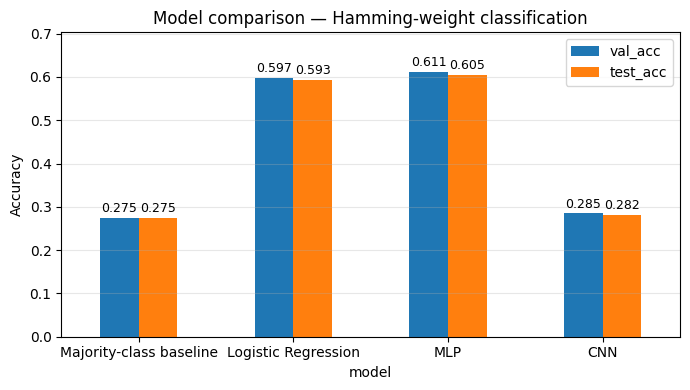

In [10]:
import pandas as pd
from pathlib import Path
Path('results').mkdir(exist_ok=True)

df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'model'})
df.to_csv('results/comparison.csv', index=False)
print(df.to_string(index=False))

ax = df.plot(x='model', y=['val_acc', 'test_acc'], kind='bar', figsize=(7, 4), rot=0)
ax.set_ylabel('Accuracy'); ax.set_title('Model comparison — Hamming-weight classification')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2, fontsize=9)
ax.set_ylim(0, max(df[['val_acc','test_acc']].max()) * 1.15)
plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig('results/comparison.png', dpi=120, bbox_inches='tight')
plt.show()

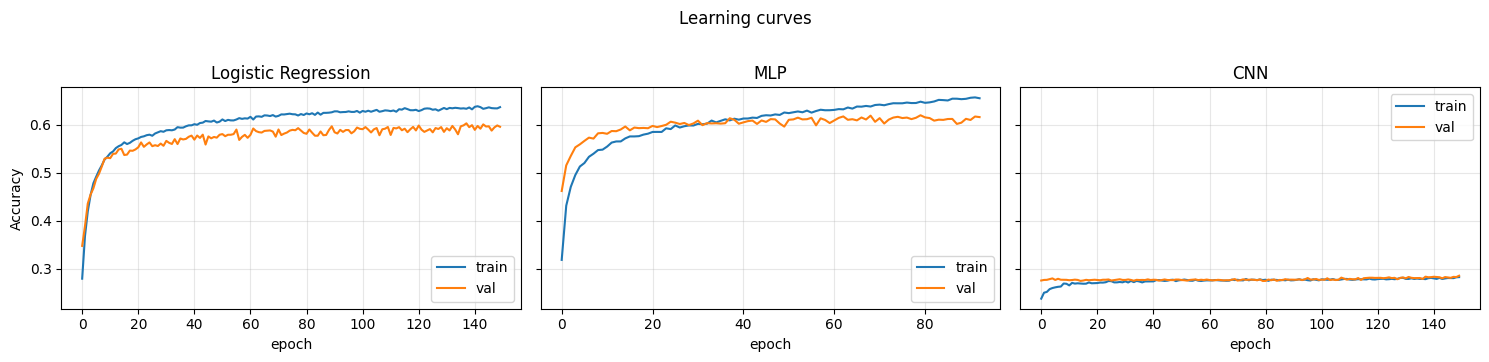

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['accuracy'],     label='train')
    ax.plot(hist.history['val_accuracy'], label='val')
    ax.set_title(name); ax.set_xlabel('epoch'); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel('Accuracy')
plt.suptitle('Learning curves', y=1.02); plt.tight_layout()
plt.savefig('results/learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()